In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd

from src.data import load_wikitext, get_continuous_text, get_prompt_batch
from src.model import load_model, load_tokenizer, print_model_config


/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset, tokenizer, and model
train_data = load_wikitext('train')
tokenizer = load_tokenizer()
model = load_model()

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 175.54it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


In [3]:
# printing model architecture
print_model_config(model)

=== Model Configuration ===
Number of layers:          36
Attention heads (Q):       32
Key-Value heads:           8
Hidden size:               2560
Intermediate size (FFN):   9728
Vocab size:                151936
Max position embeddings:   40960
Head dim:                  128


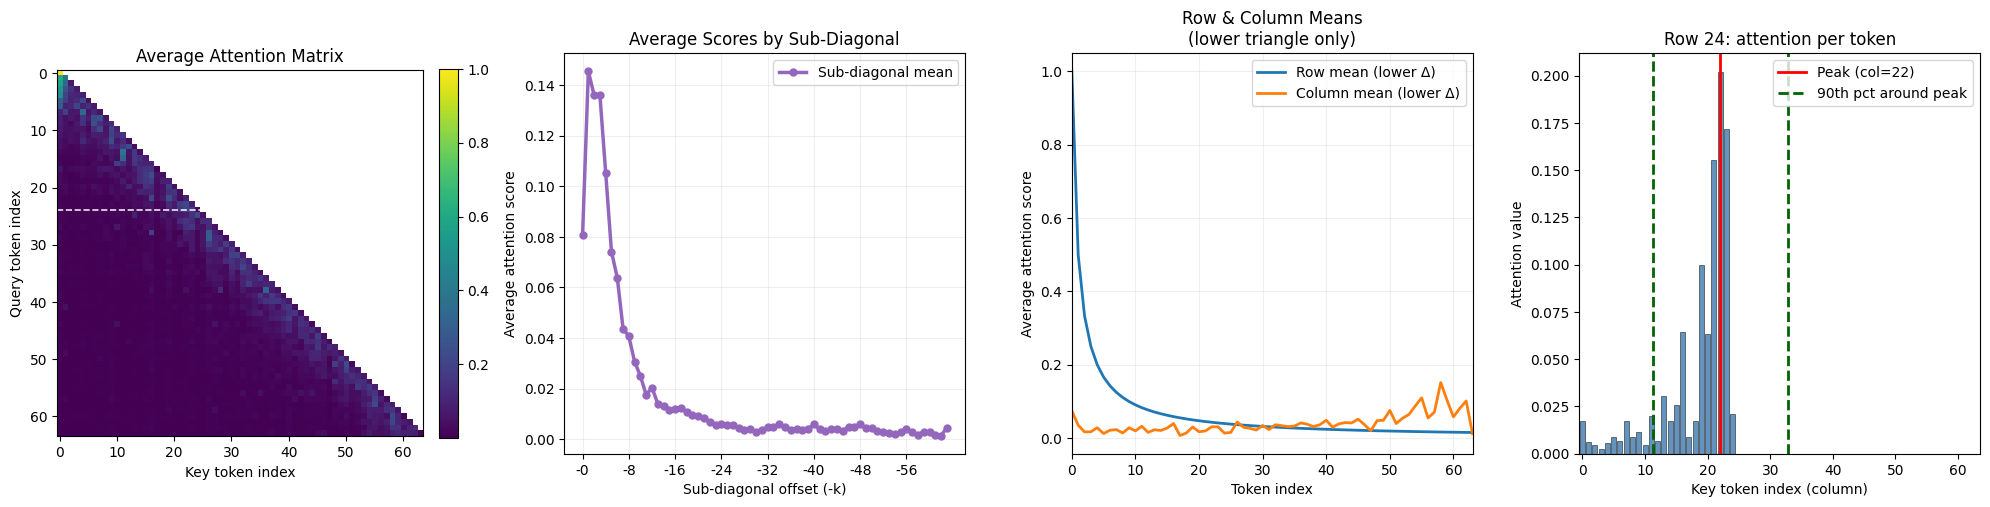

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def average_attention_matrix_over_prompts(
    model,
    tokenizer,
    prompts,
    layer_idx,
    head_idx,
    seq_len=128,
):
    """
    Compute average attention matrix for a chosen (layer, head) over multiple prompts.
    Returns a (T, T) matrix where T is the minimum sequence length observed.
    """
    device = next(model.parameters()).device
    collected = []

    model.eval()
    with torch.no_grad():
        for prompt in prompts:
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=seq_len,
                add_special_tokens=True,
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs, output_attentions=True, use_cache=False)
            # Shape per layer: [batch, heads, tokens, tokens]
            attn = outputs.attentions[layer_idx][0, head_idx].detach().float().cpu().numpy()
            collected.append(attn)

    if not collected:
        raise ValueError("No attention matrices were collected. Provide at least one prompt.")

    # Keep dimensions aligned if token lengths vary slightly across prompts.
    min_len = min(m.shape[0] for m in collected)
    cropped = [m[:min_len, :min_len] for m in collected]
    avg_attn = np.mean(cropped, axis=0)
    return avg_attn


def _weighted_percentile(values, weights, percentile):
    """Return weighted percentile for 1D arrays."""
    if len(values) == 0:
        return 0.0
    sort_idx = np.argsort(values)
    v = values[sort_idx]
    w = weights[sort_idx]
    w_sum = w.sum()
    if w_sum <= 0:
        return float(np.percentile(v, percentile))
    cdf = np.cumsum(w) / w_sum
    q = percentile / 100.0
    return float(np.interp(q, cdf, v))


def _print_row_col_stats(avg_attn, row_idx):
    """Print mean/median/std for each row and each column in lower triangle."""
    n = avg_attn.shape[0]

    print("\n=== Row Statistics (lower triangle: col <= row) ===")
    print(f"{'row':>4} | {'mean':>12} | {'median':>12} | {'std':>12}")
    print("-" * 52)
    for i in range(n):
        vals = avg_attn[i, : i + 1]
        print(f"{i:4d} | {vals.mean():12.6f} | {np.median(vals):12.6f} | {vals.std():12.6f}")

    print("\n=== Column Statistics (lower triangle: row >= col) ===")
    print(f"{'col':>4} | {'mean':>12} | {'median':>12} | {'std':>12}")
    print("-" * 52)
    for j in range(n):
        vals = avg_attn[j:, j]
        print(f"{j:4d} | {vals.mean():12.6f} | {np.median(vals):12.6f} | {vals.std():12.6f}")

    row_vals_full = avg_attn[row_idx, :]
    print("\n=== Selected Row Statistics (full row) ===")
    print(
        f"row={row_idx} | mean={row_vals_full.mean():.6f} | "
        f"median={np.median(row_vals_full):.6f} | std={row_vals_full.std():.6f}"
    )


def plot_attention_and_row_barplot(
    avg_attn,
    row_idx,
    percentile=90,
    cmap="viridis",
    print_stats=True,
):
    """
    Plot:
    1) average attention matrix,
    2) average scores for each sub-diagonal in lower triangle,
    3) row and column means from lower triangle,
    4) per-cell barplot for one selected row.
    """
    if row_idx < 0 or row_idx >= avg_attn.shape[0]:
        raise IndexError(f"row_idx={row_idx} out of bounds for matrix size {avg_attn.shape[0]}")

    n = avg_attn.shape[0]
    lower_mask = np.tril(np.ones((n, n), dtype=bool), k=0)

    # Lower triangle row/column means
    row_sums = (avg_attn * lower_mask).sum(axis=1)
    row_counts = lower_mask.sum(axis=1)
    row_means = row_sums / np.maximum(row_counts, 1)

    col_sums = (avg_attn * lower_mask).sum(axis=0)
    col_counts = lower_mask.sum(axis=0)
    col_means = col_sums / np.maximum(col_counts, 1)

    # Compute sub-diagonal averages for lower triangle
    diag_means = []
    for k in range(n):
        diag_vals = np.diag(avg_attn, k=-k)
        if len(diag_vals) > 0:
            diag_means.append(diag_vals.mean())

    if print_stats:
        _print_row_col_stats(avg_attn, row_idx)

    row_values = avg_attn[row_idx]
    x_idx = np.arange(len(row_values), dtype=float)

    peak_pos = int(np.argmax(row_values))

    # Symmetric percentile interval in index-space around the peak index.
    distances_idx = np.abs(x_idx - peak_pos)
    weights = np.maximum(row_values, 0.0) + 1e-12
    radius_idx = _weighted_percentile(distances_idx, weights, percentile)
    left_x = max(0.0, peak_pos - radius_idx)
    right_x = min(len(row_values) - 1.0, peak_pos + radius_idx)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Panel 1: Mask strict upper triangle and render it in white.
    upper_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    attn_masked = np.ma.array(avg_attn, mask=upper_mask)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")

    im = axes[0].imshow(attn_masked, cmap=cmap_obj, aspect="equal")
    axes[0].set_title("Average Attention Matrix")
    axes[0].set_xlabel("Key token index")
    axes[0].set_ylabel("Query token index")
    axes[0].axhline(row_idx, color="white", linestyle="--", linewidth=1.2, alpha=0.9)
    axes[0].set_box_aspect(1)
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # Panel 2: Sub-diagonal averages
    axes[1].plot(range(len(diag_means)), diag_means, color="tab:purple", linewidth=2.5, 
                 marker="o", markersize=5, label="Sub-diagonal mean")
    axes[1].set_title("Average Scores by Sub-Diagonal")
    axes[1].set_xlabel("Sub-diagonal offset (-k)")
    axes[1].set_ylabel("Average attention score")
    axes[1].set_box_aspect(1)
    axes[1].grid(alpha=0.2)
    axes[1].set_xticks(range(0, len(diag_means), max(1, len(diag_means) // 8)))
    axes[1].set_xticklabels([f"-{i}" for i in range(0, len(diag_means), max(1, len(diag_means) // 8))])
    axes[1].legend()

    # Panel 3: Row and column means
    idx = np.arange(n)
    axes[2].plot(idx, row_means, color="tab:blue", linewidth=2, label="Row mean (lower Δ)")
    axes[2].plot(idx, col_means, color="tab:orange", linewidth=2, label="Column mean (lower Δ)")
    axes[2].set_title("Row & Column Means\n(lower triangle only)")
    axes[2].set_xlabel("Token index")
    axes[2].set_ylabel("Average attention score")
    axes[2].set_xlim(0, n - 1)
    axes[2].set_box_aspect(1)
    axes[2].grid(alpha=0.2)
    axes[2].legend()

    # Panel 4: Row barplot
    axes[3].bar(
        x_idx,
        row_values,
        color="steelblue",
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85,
    )
    axes[3].axvline(peak_pos, color="red", linestyle="-", linewidth=2,
                    label=f"Peak (col={peak_pos})")
    axes[3].axvline(left_x, color="darkgreen", linestyle="--", linewidth=2,
                    label=f"{percentile}th pct around peak")
    axes[3].axvline(right_x, color="darkgreen", linestyle="--", linewidth=2)
    axes[3].set_title(f"Row {row_idx}: attention per token")
    axes[3].set_xlabel("Key token index (column)")
    axes[3].set_ylabel("Attention value")
    axes[3].set_xlim(-0.5, len(row_values) - 0.5)
    axes[3].set_box_aspect(1)
    axes[3].legend()

    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage (edit these)
# -----------------------------
n_prompts = 5
seq_len = 64
layer_idx = 0
head_idx = 10
row_idx = 24
percentile_x = 90

prompt_batch = get_prompt_batch(
    train_data,
    tokenizer,
    n_prompts=n_prompts,
    num_tokens=seq_len,
    stride=600,
    start_idx=1000,
)
prompts = [item[0] for item in prompt_batch]

avg_attn = average_attention_matrix_over_prompts(
    model=model,
    tokenizer=tokenizer,
    prompts=prompts,
    layer_idx=layer_idx,
    head_idx=head_idx,
    seq_len=seq_len,
)

plot_attention_and_row_barplot(
    avg_attn=avg_attn,
    row_idx=row_idx,
    percentile=percentile_x,
    cmap="viridis",
    print_stats=False,
)


Row sums close to 1: True
Upper triangle all zero: True


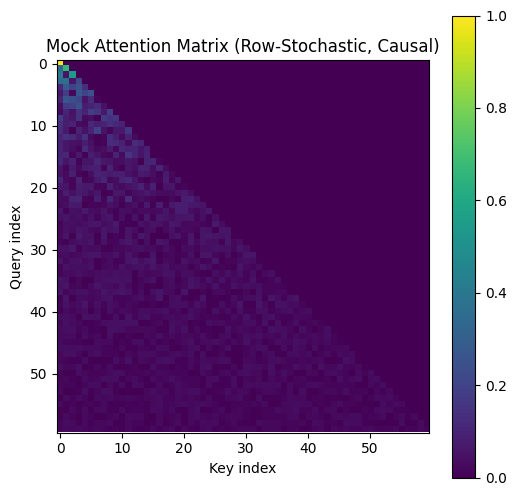

In [27]:
# Mock attention matrix generator: row-stochastic + causal support (upper triangle = 0)
import numpy as np
import matplotlib.pyplot as plt

def generate_mock_attention_matrix(
    n: int,
    noise_scale: float = 1.0,
    seed: int | None = None,
) -> np.ndarray:
    """Generate an NxN random row-stochastic matrix with strict upper triangle set to zero.

    Properties:
    1) A[i, j] = 0 for j > i (causal / lower-triangular support).
    2) Each row sums to 1 (row-stochastic).
    3) No explicit constraints on diagonal magnitude.
    """
    if n <= 0:
        raise ValueError("n must be positive")
    if noise_scale <= 0.0:
        raise ValueError("noise_scale must be positive")

    rng = np.random.default_rng(seed)
    a = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        # Fill only lower-triangular part of row i: columns 0..i
        a[i, : i + 1] = rng.random(i + 1) * noise_scale

    # Enforce exact causal structure
    a = np.tril(a, k=0)

    # Normalize rows to make the matrix row-stochastic
    row_sums = a.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise RuntimeError("Encountered a zero-sum row before normalization")
    a /= row_sums

    return a


test = generate_mock_attention_matrix(n=60, noise_scale=1.0, seed=42)

print("Row sums close to 1:", np.allclose(test.sum(axis=1), 1.0))
print("Upper triangle all zero:", np.allclose(np.triu(test, k=1), 0.0))

plt.figure(figsize=(6, 6))
plt.imshow(test, cmap="viridis", aspect="equal")
plt.colorbar()
plt.title("Mock Attention Matrix (Row-Stochastic, Causal)")
plt.xlabel("Key index")
plt.ylabel("Query index")
plt.show()

In [28]:
import torch
import numpy as np

def compute_geometry_of_reason_metrics(avg_attn: np.ndarray, X=None):
    N = avg_attn.shape[0]
    if N < 2: return {"fiedler_value": 0.0, "smoothness": 0.0, "hfer": 0.0, "spectral_entropy": 0.0}

    # FIX: Se X non è fornito, generiamo un segnale casuale di shape (N, 64)
    if X is None:
        np.random.seed(42)
        X = np.random.randn(N, 64)
        
    A_t = torch.tensor(avg_attn, dtype=torch.float32)
    X_t = torch.tensor(X, dtype=torch.float32)

    # 1. Simmetrizzazione
    W = (A_t + A_t.transpose(-1, -2)) / 2.0
    
    # 2. Laplaciano Normalizzato
    d = W.sum(dim=-1)
    d_inv_sqrt = torch.where(d > 1e-10, 1.0 / torch.sqrt(d), torch.zeros_like(d))
    D_inv_sqrt = torch.diag(d_inv_sqrt)
    
    I = torch.eye(N, device=A_t.device, dtype=A_t.dtype)
    L_sym = I - D_inv_sqrt @ W @ D_inv_sqrt
    
    # 3. Autovalori e Autovettori
    eigenvalues, eigenvectors = torch.linalg.eigh(L_sym)
    
    # Metrica 1: Fiedler Value
    fiedler_value = eigenvalues[1].item()
    
    # Metrica 2: Smoothness
    X_norm = X_t / torch.linalg.norm(X_t, dim=-1, keepdim=True).clamp(min=1e-10) 
    dirichlet_energy = torch.trace(X_norm.transpose(-1, -2) @ L_sym @ X_norm)
    signal_energy = torch.trace(X_norm.transpose(-1, -2) @ X_norm)
    smoothness = (dirichlet_energy / signal_energy).item() if signal_energy > 0 else 0.0
    
    # Metrica 3: HFER
    X_hat = eigenvectors.transpose(-1, -2) @ X_norm
    energy_spectrum = torch.sum(X_hat ** 2, dim=-1) 
    cutoff_idx = N // 2
    total_energy = torch.sum(energy_spectrum)
    high_freq_energy = torch.sum(energy_spectrum[cutoff_idx:])
    hfer = (high_freq_energy / total_energy).item() if total_energy > 0 else 0.0
    
    # Metrica 4: Spectral Entropy
    p = energy_spectrum / total_energy.clamp(min=1e-10)
    p_safe = p[p > 1e-10]
    spectral_entropy = (-torch.sum(p_safe * torch.log(p_safe))).item()
    normalized_spectral_entropy = spectral_entropy / np.log(N)

    return {
        "fiedler_value": fiedler_value,
        "smoothness": smoothness,
        "hfer": hfer,
        "spectral_entropy": normalized_spectral_entropy
    }

# ==========================================
# ESECUZIONE (Senza passare X, sfruttando il default)
# ==========================================
metrics = compute_geometry_of_reason_metrics(test)

print("="*45)
print(" GEOMETRY OF REASON - SPECTRAL SIGNATURES")
print("="*45)
print(f" Fiedler Value (Connettività) : {metrics['fiedler_value']:.5f}")
print(f" Graph Smoothness             : {metrics['smoothness']:.5f}")
print(f" High-Freq Energy Ratio (HFER): {metrics['hfer']:.5f}")
print(f" Spectral Entropy             : {metrics['spectral_entropy']:.5f}")
print("="*45)


 GEOMETRY OF REASON - SPECTRAL SIGNATURES
 Fiedler Value (Connettività) : 0.59381
 Graph Smoothness             : 0.94964
 High-Freq Energy Ratio (HFER): 0.50907
 Spectral Entropy             : 0.99643
